Importing Libraries

In [1]:
# !pip install -r requirements.txt

In [2]:
# Import all libraries
from semantic_kernel import Kernel
from semantic_kernel.connectors.ai.open_ai import AzureChatCompletion
# from semantic_kernel.core_plugins.math_plugin import MathPlugin
from semantic_kernel.core_plugins.time_plugin import TimePlugin
from semantic_kernel.utils.logging import setup_logging
import logging
from dotenv import load_dotenv
import os
from azure.identity import DefaultAzureCredential, get_bearer_token_provider
from semantic_kernel.contents.chat_history import ChatHistory

In [3]:
kernel = Kernel()
load_dotenv()
# For Azure OpenAI authentication using API key, use the following line:
# chat_completion = AzureChatCompletion(api_key=os.environ["AOAI_API_KEY"],deployment_name=os.environ["AOAI_DEPLOYMENT_NAME"], endpoint=os.environ["AOAI_ENDPOINT"],api_version=os.environ["AOAI_API_VERSION"])
# For Entra ID authentication, use the following line instead:
credential = DefaultAzureCredential()
token_provider = get_bearer_token_provider(
    credential, "https://cognitiveservices.azure.com/.default"
)
chat_completion = AzureChatCompletion(ad_token_provider=token_provider, deployment_name=os.environ["AOAI_DEPLOYMENT_NAME"], endpoint=os.environ["AOAI_ENDPOINT"], api_version=os.environ["AOAI_API_VERSION"])
kernel.add_service(chat_completion, "chat")

chat_history = ChatHistory()

# Setup logging
setup_logging()
logger = logging.getLogger("kernel")
logger.setLevel(logging.DEBUG)

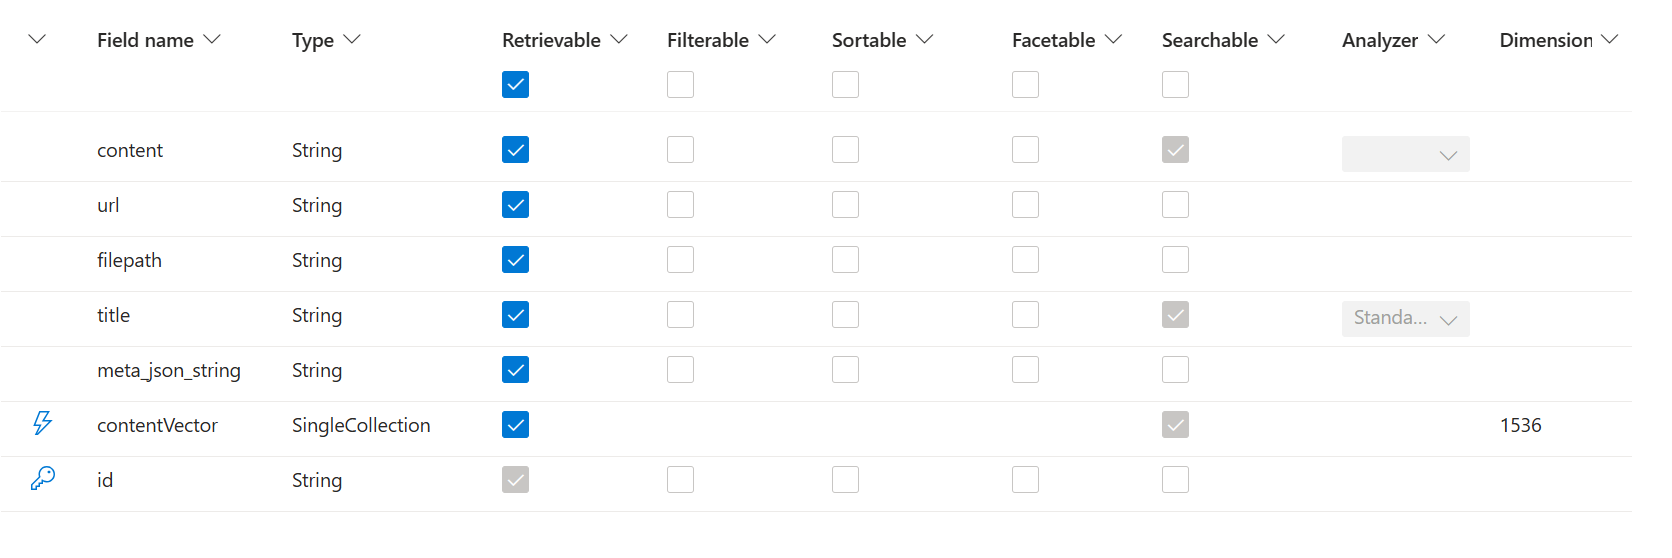 Index schema

## Create pydantic schema for the index
This schema is used to map the search results to the model

In [4]:
# Create SearchIndexClient and SearchClient
from azure.search.documents.aio import SearchClient
from azure.search.documents.indexes.aio import SearchIndexClient

COLLECTION_NAME = "surface-pro-index"

search_client = SearchClient(
    endpoint=os.environ["AZURE_SEARCH_ENDPOINT"],
    index_name=COLLECTION_NAME,
    credential=DefaultAzureCredential(),
)

search_index_client = SearchIndexClient(
    endpoint=os.environ["AZURE_SEARCH_ENDPOINT"],
    credential=DefaultAzureCredential(),
)

In [ ]:
from azure.search.documents import SearchClient

COLLECTION_NAME = "surface-pro-index"

search_client_sync = SearchClient(
    endpoint=os.environ["AZURE_SEARCH_ENDPOINT"],
    index_name=COLLECTION_NAME,
    credential=DefaultAzureCredential(),
)
from azure.search.documents.models import VectorizableTextQuery
vector_query = VectorizableTextQuery(text="surface pro features", k_nearest_neighbors=50, fields="contentVector")
  
results = search_client_sync.search(  
    search_text="surface pro features",  
    vector_queries= [vector_query],
    select=["content"],
    top=1
)  
  
for result in results:  
    print(f"Score: {result['@search.score']}")
    print(f"Chunk: {result['content']}")

In [22]:
from pydantic import BaseModel
from semantic_kernel.connectors.ai.open_ai import OpenAIEmbeddingPromptExecutionSettings
from semantic_kernel.data import (
    vectorstoremodel,
    VectorStoreRecordKeyField,
    VectorStoreRecordDataField,
    VectorStoreRecordVectorField,
)
from typing import Annotated

@vectorstoremodel
class MySearchIndexModel(BaseModel):
    id: Annotated[str, VectorStoreRecordKeyField()]
    meta_json_string: Annotated[str, VectorStoreRecordDataField()]
    title: Annotated[str, VectorStoreRecordDataField()]
    filepath: Annotated[str, VectorStoreRecordDataField()]
    url: Annotated[str, VectorStoreRecordDataField()]
    content: Annotated[str, VectorStoreRecordDataField(has_embedding=True, embedding_property_name="contentVector", is_full_text_searchable=True)]
    contentVector: Annotated[
        list[float] | None,
        VectorStoreRecordVectorField( 
            dimensions=1536,
            local_embedding=True,
            embedding_settings={"embedding": OpenAIEmbeddingPromptExecutionSettings(dimensions=1536)}
            ),
        ] = None

In [ ]:

from semantic_kernel.connectors.memory.azure_ai_search import AzureAISearchCollection

collection = AzureAISearchCollection[str, MySearchIndexModel](collection_name=COLLECTION_NAME, 
                                                              data_model_type=MySearchIndexModel,
                                                              search_client=search_client,
                                                              search_index_client=search_index_client,)

#version of semantic kernel library has to be 1.27+
text_search = collection.create_text_search_from_vector_text_search()

## For older version do the following
# from semantic_kernel.data.vector_store_text_search import VectorStoreTextSearch

# text_search = VectorStoreTextSearch.from_vector_text_search(collection)

In [24]:
### for single function
# from semantic_kernel.functions.kernel_plugin import KernelPlugin
# plugin = KernelPlugin.from_text_search_with_search(text_search, "search")

# for multiple functions within a plugin
from semantic_kernel.functions import KernelParameterMetadata, KernelArguments
plugin = kernel.add_functions(
    plugin_name="azure_ai_search",
    functions=[
        text_search.create_search(
            description="A surface pro search engine, allows asking questions about the surface pro.",
            parameters=[
                KernelParameterMetadata(
                    name="query",
                    description="The query to search for.",
                    type="str",
                    is_required=True,
                    type_object=str
                ),
                KernelParameterMetadata(
                    name="top",
                    description="The number of results to return.",
                    type="int",
                    is_required=False,
                    type_object=int,
                    default_value=2
                ),
            ]
        )
    ]
)

If you wish to add chat as a function to the kernel, uncomment the lines below:

In [27]:
from semantic_kernel.connectors.ai.open_ai import (
    # OpenAIChatCompletion,
    OpenAIChatPromptExecutionSettings,
    # OpenAITextEmbedding,
)
from semantic_kernel.connectors.ai.function_choice_behavior import FunctionChoiceBehavior

#Adding chat as a function
chat_function = kernel.add_function(
    plugin_name="chatbot",
    function_name="chat",
    description="Chat with the surface pro assistant.",
    prompt="{{$chat_history}}{{$user_input}}",
)

execution_settings = OpenAIChatPromptExecutionSettings(function_choice_behavior=FunctionChoiceBehavior.Auto(filters={"excluded_plugins": ["chatbot"]}),
                                                       service_id="chat",
                                                       temperature=0.7,
                                                       max_tokens=1500,)

In [25]:
from semantic_kernel.connectors.ai.open_ai import OpenAIChatPromptExecutionSettings
from semantic_kernel.connectors.ai.function_choice_behavior import FunctionChoiceBehavior

execution_settings = OpenAIChatPromptExecutionSettings(
    function_choice_behavior=FunctionChoiceBehavior.Auto(),
    service_id="chat",
    temperature=0.7,
    max_tokens=1500,
)

## Lets test the RAG

In [31]:
chat_history.add_system_message("You are a helpful assistant that provides information about the surface pro. You do not use your internal knowledge, but only the information provided by the search engine. You can answer questions about the surface pro features and specifications.")
arguments = KernelArguments(settings=execution_settings)
questions = ["Does surface pro support Cortana Integration?", "What are the ease of access features?"]
for question in questions:
    chat_history.add_user_message(question)
    # Get the answer from the kernel
    answer = await chat_completion.get_chat_message_content(chat_history=chat_history, settings=execution_settings, kernel=kernel, arguments=arguments)
    logger.info(f"Answer: {answer}")

[2025-04-11 11:44:33 - kernel:8 - INFO] Answer: Yes, the Surface Pro supports Cortana integration. You can open Cortana by selecting the search box in the taskbar. Additionally, the Surface Pen allows you to access Cortana by clicking and holding the top button, which opens Cortana or Search if Cortana is not set up.
[2025-04-11 11:44:35 - kernel:8 - INFO] Answer: The Surface Pro offers several Ease of Access features that allow you to use the device in a way that suits your needs. These features include:

1. **Narrator**: This feature reads the text on your screen aloud, helping users who need audio assistance.

2. **Magnifier**: Magnifier enlarges your screen or specific parts of it, making words and images easier to see for individuals who require visual aid.

You can access these features by going to Start, selecting Settings, and then Ease of Access. These options make the Surface Pro more accessible to users with different needs by providing tools that enhance usability.


So far we've seen how to leverage the Chat Completions object to interact with the Kernel, note in cell 2 we added the LLM as a service to the Kernel. Below you'll see how to leverage the Kernel to answer user question.

In [32]:
for question in questions:    
    response = await kernel.invoke_prompt(
                prompt="{{$chat_history}}{{$user_input}}", user_input=question, chat_history=chat_history
            )

    if response:
        print(f"Assistant:> {response}")
        chat_history.add_user_message(str(question))
        chat_history.add_message(response.value[0])

Assistant:> Yes, the Surface Pro supports Cortana integration. You can access Cortana using the search box in the taskbar or with the Surface Pen. By clicking and holding the top button on the pen, you can open Cortana or Search, depending on its setup. This feature allows you to interact with Cortana directly from your device.
Assistant:> The Surface Pro offers several Ease of Access features designed to enhance usability:

1. **Narrator**: This feature reads the text on your screen aloud, assisting users with visual impairments by providing spoken feedback.

2. **Magnifier**: This tool enlarges parts of your screen, making words and images easier to see, which is helpful for those who have difficulty viewing small text or icons.

These features allow users to customize their interactions with the device, ensuring a more accessible and user-friendly experience.
